# FFT, Spectral Leakage and Windowing

This notebook investigates how a finite-length observation affects the spectrum computed by the FFT, why energy from a single sinusoid can spread into many frequency bins (spectral leakage), and how window functions trade frequency resolution against leakage suppression.

## Objective

The objectives of this notebook are to:

- Understand how the FFT frequency axis is built: bin spacing, observation time and amplitude scaling.
- Observe spectral leakage and relate it to the finite observation window.
- Separate two ideas that are often confused: zero-padding and frequency resolution.
- Compare common window functions using measurable figures of merit.
- Examine the practical trade-offs of windowing: dynamic range, resolving close tones, amplitude accuracy and noise floor.

## Theory

### The DFT and Its Frequency Axis

For a block of $N$ samples $x[n]$ taken at sampling frequency $f_s$, the DFT is

$$
X[k] = \sum_{n=0}^{N-1} x[n]\, e^{-j 2\pi k n / N}, \qquad k = 0, 1, \dots, N-1
$$

The FFT is simply a fast algorithm for computing this sum. Bin $k$ corresponds to the frequency

$$
f_k = k\,\frac{f_s}{N}
$$

so the bin spacing and the observation time are related by

$$
\Delta f = \frac{f_s}{N} = \frac{1}{T_{obs}}, \qquad T_{obs} = \frac{N}{f_s}
$$

For a real sinusoid $x[n] = A\cos(2\pi f_0 n / f_s)$ whose frequency falls exactly on a bin, the magnitude at that bin is $|X[k_0]| = A N / 2$. Dividing by $N/2$ therefore gives an amplitude spectrum that reads $A$ directly.

### Finite Observation as a Window

A computer never sees an infinitely long signal. Taking $N$ samples is equivalent to multiplying the infinite signal by a rectangular window $w[n]$ that is 1 for $0 \le n \le N-1$ and 0 elsewhere:

$$
x_N[n] = x[n]\, w[n]
$$

Multiplication in time is convolution in frequency, so the spectrum of the observed block is the true spectrum convolved with the spectrum of the window:

$$
X_N(f) = X(f) * W(f)
$$

For the rectangular window, $W(f)$ is the Dirichlet kernel (a periodic sinc):

$$
|W(f)| = \left| \frac{\sin(\pi f N / f_s)}{\sin(\pi f / f_s)} \right|
$$

The DFT bins are samples of $X_N(f)$ at $f = k f_s / N$. Equivalently, the DFT implicitly treats the $N$ samples as one period of a periodic signal.

### Window Functions

Instead of the rectangular window, a tapered window $w[n]$ can be applied before the FFT:

$$
X_w[k] = \sum_{n=0}^{N-1} w[n]\, x[n]\, e^{-j 2\pi k n / N}
$$

Windows are compared using the following figures of merit:

- **Main-lobe width:** the width of the central lobe of $|W(f)|$, given in bins (−3 dB width, or half-width to the first null).
- **Peak sidelobe level (PSL):** the highest sidelobe relative to the main-lobe peak, in dB.
- **Coherent gain (CG):** the DC gain of the window, which scales the amplitude of a tone:

$$
CG = \frac{1}{N}\sum_{n=0}^{N-1} w[n]
$$

- **Equivalent noise bandwidth (ENBW):** the width of a rectangular filter that passes the same white-noise power as one window bin:

$$
ENBW = N\,\frac{\sum w^2[n]}{\left(\sum w[n]\right)^2} \quad \text{[bins]}
$$

- **Scalloping loss:** the drop in the peak reading when a tone falls exactly halfway between two bins:

$$
SL = 20\log_{10}\left|\frac{W(0.5\,\Delta f)}{W(0)}\right|
$$

When a window is used, the amplitude spectrum is normalized by $\sum w[n] / 2$ instead of $N/2$, so that a sinusoid on a bin still reads its true amplitude.

### Zero-Padding

Zero-padding appends zeros to the $N$ samples before computing an FFT of length $N_{FFT} > N$. The bin spacing becomes $f_s / N_{FFT}$, but the underlying $X_N(f)$ is still determined by the original $N$ samples.

### Note on Window Definitions

For spectral analysis, the "periodic" (DFT-even) form of a window is used. In SciPy this is `signal.get_window(name, N, fftbins=True)`, which is the default.

## Setup

Imports and a few helper functions used throughout the notebook.

- `amplitude_spectrum` returns a one-sided spectrum scaled so that a sinusoid of amplitude $A$ on a bin reads $A$, for any window.
- `window_response` returns the window spectrum on a fine grid (heavy zero-padding), with the frequency axis expressed in bins.
- `window_metrics` measures the figures of merit defined in the Theory section numerically from the window samples.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

rng = np.random.default_rng(seed=0)


def db20(x, floor=1e-12):
    # Amplitude to dB
    return 20 * np.log10(np.maximum(np.abs(x), floor))


def get_win(window, N):
    # Periodic (DFT-even) window for spectral analysis
    return signal.get_window(window, N, fftbins=True)


def amplitude_spectrum(x, fs, window="boxcar", nfft=None):
    # One-sided amplitude spectrum of a real signal.
    # A sinusoid of amplitude A that falls exactly on a bin reads A.
    N = len(x)
    w = get_win(window, N)
    nfft = N if nfft is None else nfft

    X = np.fft.rfft(x * w, n=nfft)
    amp = 2 * np.abs(X) / np.sum(w)
    amp[0] /= 2                    # DC is not doubled
    if nfft % 2 == 0:
        amp[-1] /= 2               # Nyquist bin is not doubled

    f = np.fft.rfftfreq(nfft, d=1 / fs)
    return f, amp


def window_response(window, N, oversample=64):
    # Window spectrum on a fine grid, normalized to 0 dB at its peak.
    # Frequency axis is in bins (multiples of fs/N).
    w = get_win(window, N)
    M = N * oversample
    W = np.fft.fftshift(np.fft.fft(w, M))
    bins = np.fft.fftshift(np.fft.fftfreq(M, d=1 / N))
    return bins, db20(W / np.max(np.abs(W)))


def window_metrics(window, N, oversample=64):
    # Measure window figures of merit numerically
    w = get_win(window, N)
    M = N * oversample

    W = np.abs(np.fft.fft(w, M))[: M // 2]
    W = W / W[0]
    W_db = db20(W)
    bins = np.arange(M // 2) / oversample

    # -3 dB main-lobe width (two-sided)
    i_3db = np.argmax(W_db < -3.0)
    bw_3db = 2 * bins[i_3db]

    # First null: first local minimum that is well below the main-lobe peak
    rising = (np.diff(W) > 0) & (W_db[:-1] < -30)
    i_null = np.argmax(rising)
    null_halfwidth = bins[i_null]

    # Highest sidelobe beyond the first null
    psl = np.max(W_db[i_null:])

    return {
        "bw_3db_bins": bw_3db,
        "null_halfwidth_bins": null_halfwidth,
        "psl_db": psl,
        "coherent_gain": np.sum(w) / N,
        "enbw_bins": N * np.sum(w**2) / np.sum(w) ** 2,
        "scalloping_loss_db": W_db[oversample // 2],
    }


plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

## Experiment 1: FFT Frequency Axis and an On-Bin Tone

Generate a sinusoid whose frequency falls exactly on an FFT bin, i.e. the record contains an integer number of cycles.

Build the frequency axis, look at the raw two-sided FFT and the scaled one-sided amplitude spectrum, and verify the amplitude scaling and Parseval's theorem numerically.

In [2]:
# Signal parameters
fs = 1000      # Hz
N = 100        # samples
A = 1.5        # amplitude
f0 = 100       # Hz

n = np.arange(N)
t = n / fs
x_on = A * np.cos(2 * np.pi * f0 * t)

delta_f = fs / N
T_obs = N / fs

print(f"Bin spacing:        {delta_f:.2f} Hz")
print(f"Observation time:   {T_obs * 1e3:.1f} ms")
print(f"Tone bin index:     f0 / delta_f = {f0 / delta_f:.2f}")
print(f"Cycles in record:   f0 * T_obs = {f0 * T_obs:.2f}")

# Raw FFT
X = np.fft.fft(x_on)
k_peak = np.argmax(np.abs(X[: N // 2]))

print(f"\nRaw |X| at peak bin: {np.abs(X[k_peak]):.3f}")
print(f"Expected A*N/2:      {A * N / 2:.3f}")

# Parseval's theorem
energy_time = np.sum(np.abs(x_on) ** 2)
energy_freq = np.sum(np.abs(X) ** 2) / N

print(f"\nEnergy (time domain):      {energy_time:.6f}")
print(f"Energy (frequency domain): {energy_freq:.6f}")

Bin spacing:        10.00 Hz
Observation time:   100.0 ms
Tone bin index:     f0 / delta_f = 10.00
Cycles in record:   f0 * T_obs = 10.00

Raw |X| at peak bin: 75.000
Expected A*N/2:      75.000

Energy (time domain):      112.500000
Energy (frequency domain): 112.500000


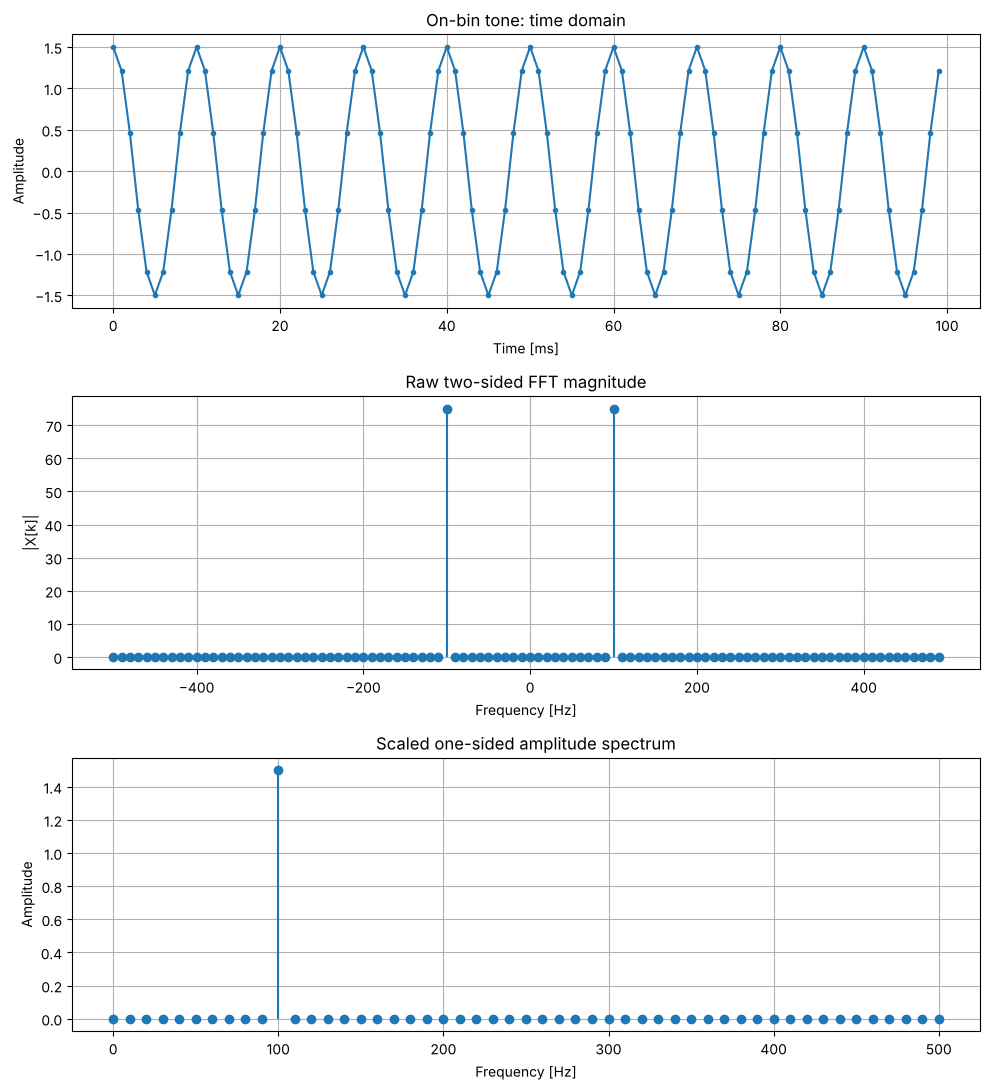

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(10, 11))

# Time domain
axes[0].plot(t * 1e3, x_on, marker=".")
axes[0].set_xlabel("Time [ms]")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("On-bin tone: time domain")

# Raw two-sided FFT (fftshift puts negative frequencies on the left)
f_two_sided = np.fft.fftshift(np.fft.fftfreq(N, d=1 / fs))
axes[1].stem(f_two_sided, np.fft.fftshift(np.abs(X)), basefmt=" ")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("|X[k]|")
axes[1].set_title("Raw two-sided FFT magnitude")

# Scaled one-sided amplitude spectrum
f_one, amp_on = amplitude_spectrum(x_on, fs)
axes[2].stem(f_one, amp_on, basefmt=" ")
axes[2].set_xlabel("Frequency [Hz]")
axes[2].set_ylabel("Amplitude")
axes[2].set_title("Scaled one-sided amplitude spectrum")

plt.tight_layout()
plt.show()

### Observation

- Since cosine is made of two different exponentials (Euler's formula), one exponential represents +100 Hz frequency and the other represents -100 Hz.
- According to (A/2)*N formula, amplitudes get distributed as 75 to both frequency sides.
- For a real valued signal, negative side is a mirror image of positive side (X(-k)=X*(k)). So the negative side does not carry any new information and can be ignored.
- Add amplitude of the negative side to the positive side and un-sample by dividing the result by N (A=(75*2)/100=1.5)

## Experiment 2: Off-Bin Tone and Spectral Leakage

Shift the tone frequency by half a bin so that the record no longer contains an integer number of cycles.

Compare the on-bin and off-bin tones in two ways:

1. In the time domain, repeat the record twice to visualize the periodic signal the DFT implicitly assumes.
2. In the frequency domain, plot both amplitude spectra in dB.

The purpose is to observe what happens to the spectrum of a pure sinusoid when its frequency does not coincide with a bin.

On-bin tone:  100 Hz  -> 10.0 cycles in the record
Off-bin tone: 105 Hz  -> 10.5 cycles in the record


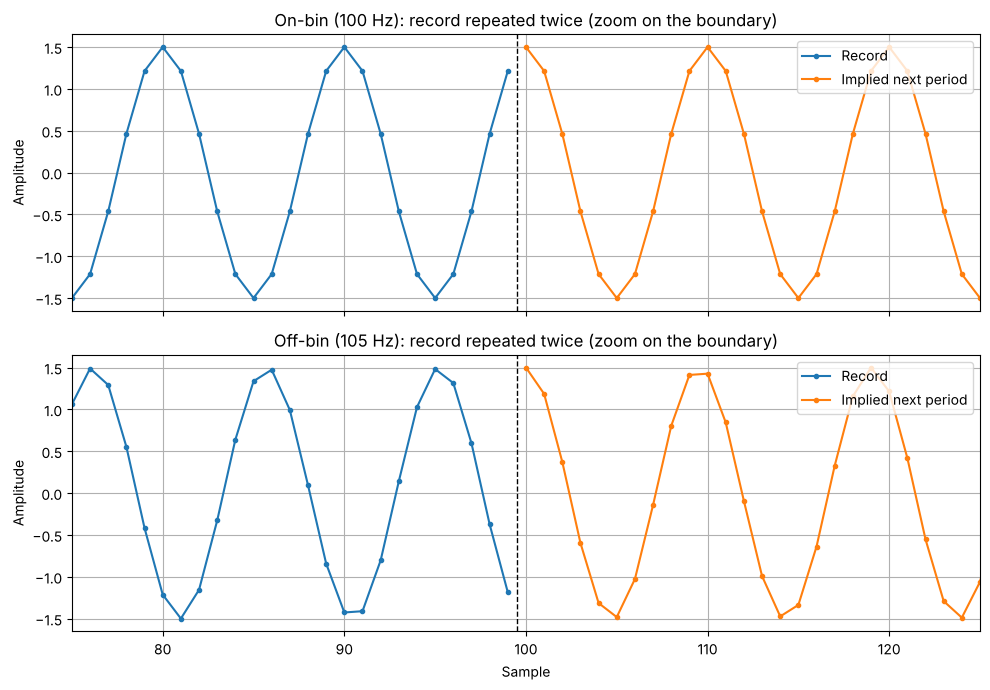

In [4]:
f_off = 105    # Hz, half a bin away from 100 Hz
x_off = A * np.cos(2 * np.pi * f_off * t)

print(f"On-bin tone:  {f0} Hz  -> {f0 * T_obs:.1f} cycles in the record")
print(f"Off-bin tone: {f_off} Hz  -> {f_off * T_obs:.1f} cycles in the record")

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

n_two = np.arange(2 * N)

for ax, x, label in zip(axes, [x_on, x_off], ["On-bin (100 Hz)", "Off-bin (105 Hz)"]):
    x_repeated = np.tile(x, 2)
    ax.plot(n_two[:N], x_repeated[:N], marker=".", label="Record")
    ax.plot(n_two[N:], x_repeated[N:], marker=".", label="Implied next period")
    ax.axvline(N - 0.5, color="k", linestyle="--", linewidth=1)
    ax.set_xlim(N - 25, N + 25)
    ax.set_ylabel("Amplitude")
    ax.set_title(f"{label}: record repeated twice (zoom on the boundary)")
    ax.legend(loc="upper right")

axes[1].set_xlabel("Sample")
plt.tight_layout()
plt.show()

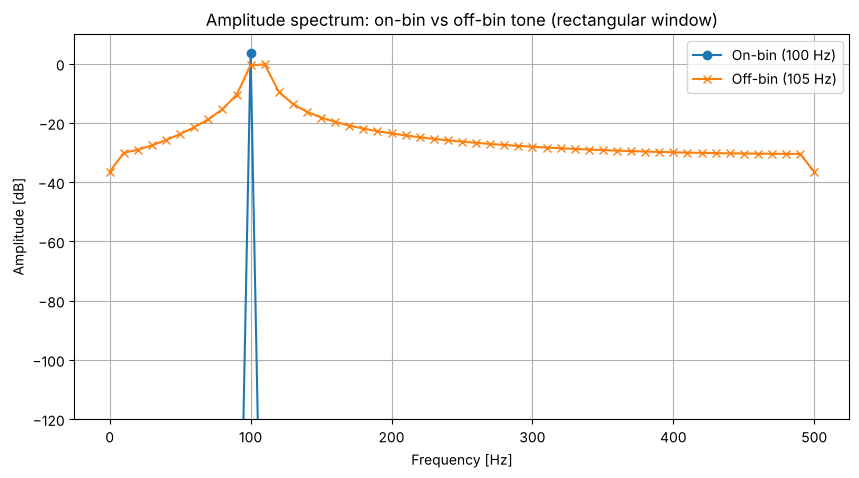

On-bin : peak reading = 1.500 (true A = 1.5), bins above -40 dB re A = 1
Off-bin: peak reading = 0.974 (true A = 1.5), bins above -40 dB re A = 49


In [5]:
f_one, amp_on = amplitude_spectrum(x_on, fs)
_, amp_off = amplitude_spectrum(x_off, fs)

plt.figure(figsize=(10, 5))
plt.plot(f_one, db20(amp_on), marker="o", label="On-bin (100 Hz)")
plt.plot(f_one, db20(amp_off), marker="x", label="Off-bin (105 Hz)")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude [dB]")
plt.title("Amplitude spectrum: on-bin vs off-bin tone (rectangular window)")
plt.ylim(-120, 10)
plt.legend()
plt.show()

for label, amp in [("On-bin ", amp_on), ("Off-bin", amp_off)]:
    print(
        f"{label}: peak reading = {np.max(amp):.3f} (true A = {A}), "
        f"bins above -40 dB re A = {np.sum(db20(amp / A) > -40)}"
    )

### Observation *(AI-assisted)

- The on-bin tone (100 Hz) contains exactly 10 cycles in the record, so it accurately catches the real signal. The off-bin tone (105 Hz) contains 10.5 cycles, creating errors when representing the real signal and discontinuities between the record and the implied next period.
- On-bin peak reading is 1.500 for 100 Hz freq. component meanwhile for off-bin case, peak reading is 0.974 and the total energy is spread among 49 frequency components.
- The periodic extension assumed by the DFT contains some discontinuities. Sudden jumps and discontinuities need a lot of frequency components, according to Fourier analysis. So the off-bin case distributes the energy to various frequencies, so the energy of a single tone spreads over many bins as weaker components.
- Because real signals almost never fall exactly on a bin, leakage is generally the norm and on-bin case is an exception.

## Experiment 3: Leakage vs. Fractional Bin Offset

Sweep the tone frequency continuously from one bin to the next (fractional offset $\delta$ from 0 to 1 bin) using the rectangular window.

For each offset, measure:

- the peak bin reading in dB relative to the true amplitude,
- the percentage of the total spectral energy that falls outside the peak bin,
- the percentage that falls outside the three bins centered on the peak.

The purpose is to see how the amount of leakage depends on where the tone sits relative to the bin grid.

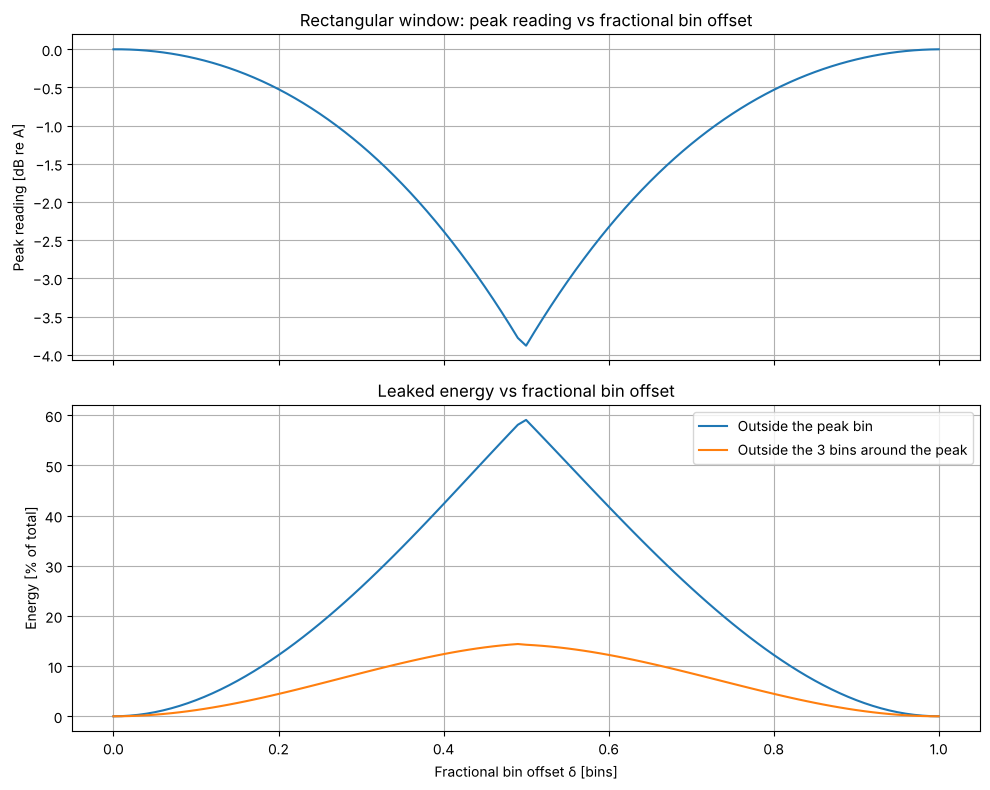

At δ = 0.5 bin: peak reading = -3.88 dB, energy outside peak bin = 59.1 %, outside 3 bins = 14.3 %


In [6]:
k0 = 20                                   # base bin
offsets = np.linspace(0, 1, 101)          # fractional bin offset

peak_db = []
outside_peak_pct = []
outside_3bins_pct = []

for d in offsets:
    f_test = (k0 + d) * delta_f
    x = np.cos(2 * np.pi * f_test * t)
    _, amp = amplitude_spectrum(x, fs)

    power = amp**2
    total = np.sum(power)
    k_pk = np.argmax(amp)

    peak_db.append(db20(amp[k_pk]))
    outside_peak_pct.append(100 * (1 - power[k_pk] / total))
    outside_3bins_pct.append(100 * (1 - np.sum(power[k_pk - 1 : k_pk + 2]) / total))

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(offsets, peak_db)
axes[0].set_ylabel("Peak reading [dB re A]")
axes[0].set_title("Rectangular window: peak reading vs fractional bin offset")

axes[1].plot(offsets, outside_peak_pct, label="Outside the peak bin")
axes[1].plot(offsets, outside_3bins_pct, label="Outside the 3 bins around the peak")
axes[1].set_xlabel("Fractional bin offset δ [bins]")
axes[1].set_ylabel("Energy [% of total]")
axes[1].set_title("Leaked energy vs fractional bin offset")
axes[1].legend()

plt.tight_layout()
plt.show()

i_half = np.argmin(np.abs(offsets - 0.5))
print(f"At δ = 0.5 bin: peak reading = {peak_db[i_half]:.2f} dB, "
      f"energy outside peak bin = {outside_peak_pct[i_half]:.1f} %, "
      f"outside 3 bins = {outside_3bins_pct[i_half]:.1f} %")

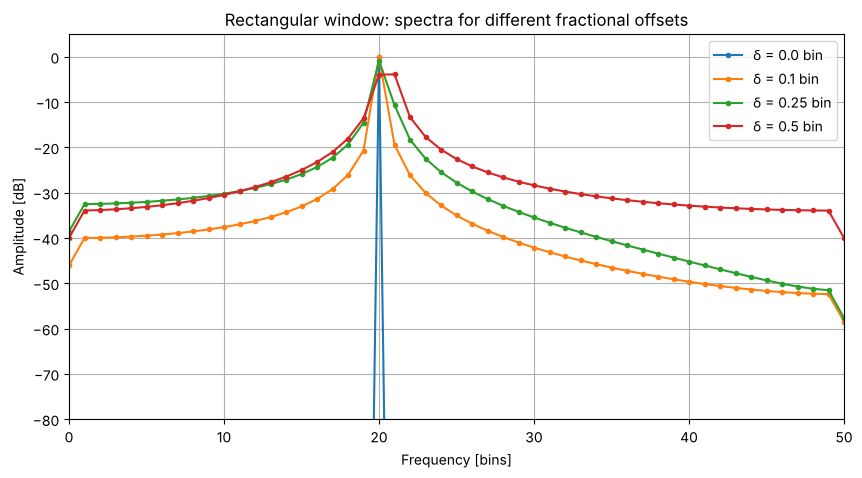

In [7]:
# Spectra for a few selected offsets
plt.figure(figsize=(10, 5))

for d in [0.0, 0.1, 0.25, 0.5]:
    x = np.cos(2 * np.pi * (k0 + d) * delta_f * t)
    f_one, amp = amplitude_spectrum(x, fs)
    plt.plot(f_one / delta_f, db20(amp), marker=".", label=f"δ = {d} bin")

plt.xlabel("Frequency [bins]")
plt.ylabel("Amplitude [dB]")
plt.title("Rectangular window: spectra for different fractional offsets")
plt.xlim(0, 50)
plt.ylim(-80, 5)
plt.legend()
plt.show()

### Observation

- The main idea is, these graphs show energy leakage at off-bin intervals.
- Peak reading is correct (0 dB) at offset=0 and offset=1 because these are true bin points.
- When offset moves to off-bin intervals, peak readings start decreasing and the decay of peak reading grows as offset goes away from nearest bin point.
- Bottom plot shows that a large part of the energy goes to the bins around the peak point, at offset=0.5, peak reading becomes -3.88 dB and energy outside peak bin becomes 59.1 %.
- At the last graph, as offset grows, peak reading decays and energy leaking to other bins grow. The peak drops only several dB's but at the farther points, the drop becomes -30 / -40 dB.

## Experiment 4: Zero-Padding vs. Longer Observation

Part A: compute the spectrum of the off-bin tone from Experiment 2 with and without zero-padding, and overlay the two.

Part B: generate two equal-amplitude tones at 100 Hz and 106 Hz, which are closer than one bin apart for $N = 100$. Compare:

- $N = 100$ without zero-padding,
- $N = 100$ zero-padded to $N_{FFT} = 1600$,
- $N = 400$ real samples,
- $N = 1000$ real samples.

The purpose is to determine what zero-padding actually changes, and whether it can separate two tones that a short record cannot.

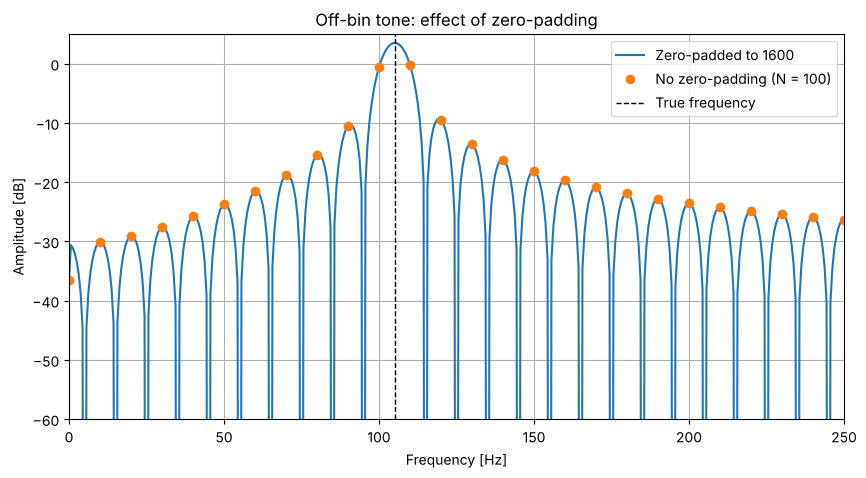

In [8]:
# Part A: zero-padding a single off-bin tone
zp_factor = 16

f_plain, amp_plain = amplitude_spectrum(x_off, fs)
f_zp, amp_zp = amplitude_spectrum(x_off, fs, nfft=N * zp_factor)

plt.figure(figsize=(10, 5))
plt.plot(f_zp, db20(amp_zp), label=f"Zero-padded to {N * zp_factor}")
plt.plot(f_plain, db20(amp_plain), "o", label=f"No zero-padding (N = {N})")
plt.axvline(f_off, color="k", linestyle="--", linewidth=1, label="True frequency")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude [dB]")
plt.title("Off-bin tone: effect of zero-padding")
plt.xlim(0, 250)
plt.ylim(-60, 5)
plt.legend()
plt.show()

N = 100, no zero-padding         -> largest peaks at [100.] Hz
N = 100, zero-padded to 1600     -> largest peaks at [103.75 121.25] Hz
N = 400 samples                  -> largest peaks at [100.   106.25] Hz
N = 1000 samples                 -> largest peaks at [100. 106.] Hz


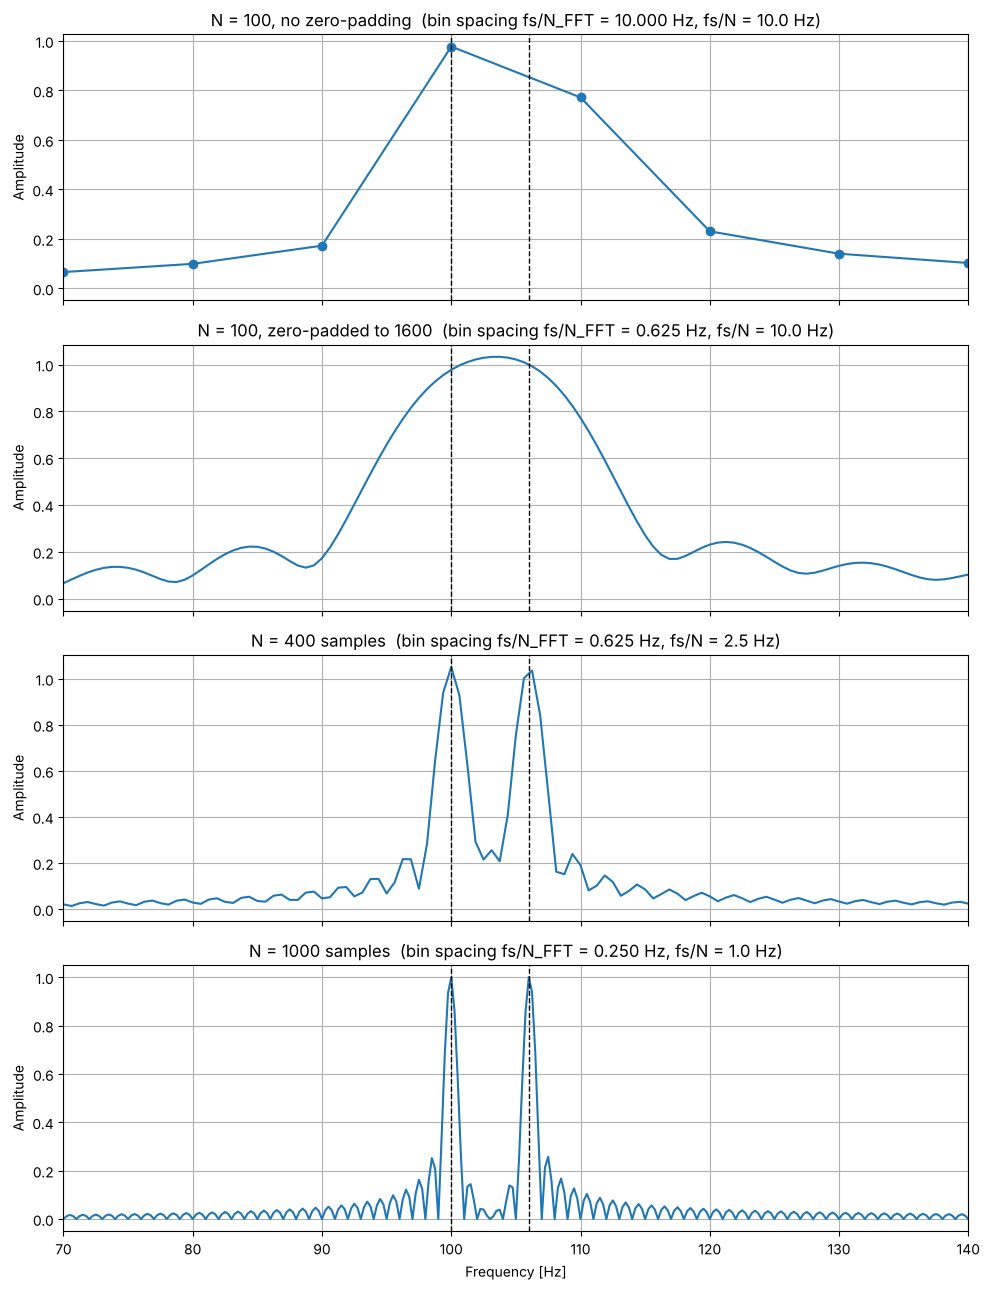

In [9]:
# Part B: two close tones
f_a, f_b = 100, 106
cases = [
    (100, 100, "N = 100, no zero-padding"),
    (100, 1600, "N = 100, zero-padded to 1600"),
    (400, 1600, "N = 400 samples"),
    (1000, 4000, "N = 1000 samples"),
]

fig, axes = plt.subplots(len(cases), 1, figsize=(10, 13), sharex=True)

for ax, (N_case, nfft, label) in zip(axes, cases):
    t_case = np.arange(N_case) / fs
    x = np.cos(2 * np.pi * f_a * t_case) + np.cos(2 * np.pi * f_b * t_case)
    f_case, amp = amplitude_spectrum(x, fs, nfft=nfft)

    style = "o-" if nfft == N_case else "-"
    ax.plot(f_case, amp, style)
    ax.axvline(f_a, color="k", linestyle="--", linewidth=1)
    ax.axvline(f_b, color="k", linestyle="--", linewidth=1)
    ax.set_xlim(70, 140)
    ax.set_ylabel("Amplitude")
    ax.set_title(f"{label}  (bin spacing fs/N_FFT = {fs / nfft:.3f} Hz, fs/N = {fs / N_case:.1f} Hz)")

    # Two largest local maxima in the plotted range
    peaks, _ = signal.find_peaks(amp)
    peaks = peaks[(f_case[peaks] > 70) & (f_case[peaks] < 140)]
    top = np.sort(f_case[peaks[np.argsort(amp[peaks])[::-1][:2]]])
    print(f"{label:32s} -> largest peaks at {np.round(top, 2)} Hz")

axes[-1].set_xlabel("Frequency [Hz]")
plt.tight_layout()
plt.show()

### Observation

- Zero padding increases bin numbers and makes the already existing sinc function more visible.
- Due to increased bin numbers, zero padding prevents scaalloping loss at the peak point but does not prevent leakage.
- If distance per bin is 10 Hz and the difference for two signals is 6 Hz, the number of samples is not enough to distincguish the two frequencies and zero padding can not distinguish them at the same number of samples.
- Because zero padding decreases bin spacing (fs/N_FFT) but does not increase number of samples and actual resolution (fs/N).
- To distinguish the two frequencies, one must increase the actual resolution and can do this by increasing number of samples, a longer reading on the signal.

## Experiment 5: Window Functions in Time and Frequency

Generate six commonly used windows: rectangular, Hann, Hamming, Blackman, Blackman–Harris (4-term) and flat-top.

Plot each window in the time domain and its spectrum on a fine grid, then measure the figures of merit defined in the Theory section directly from the window samples.

The purpose is to build a quantitative picture of what each window offers and what it costs.

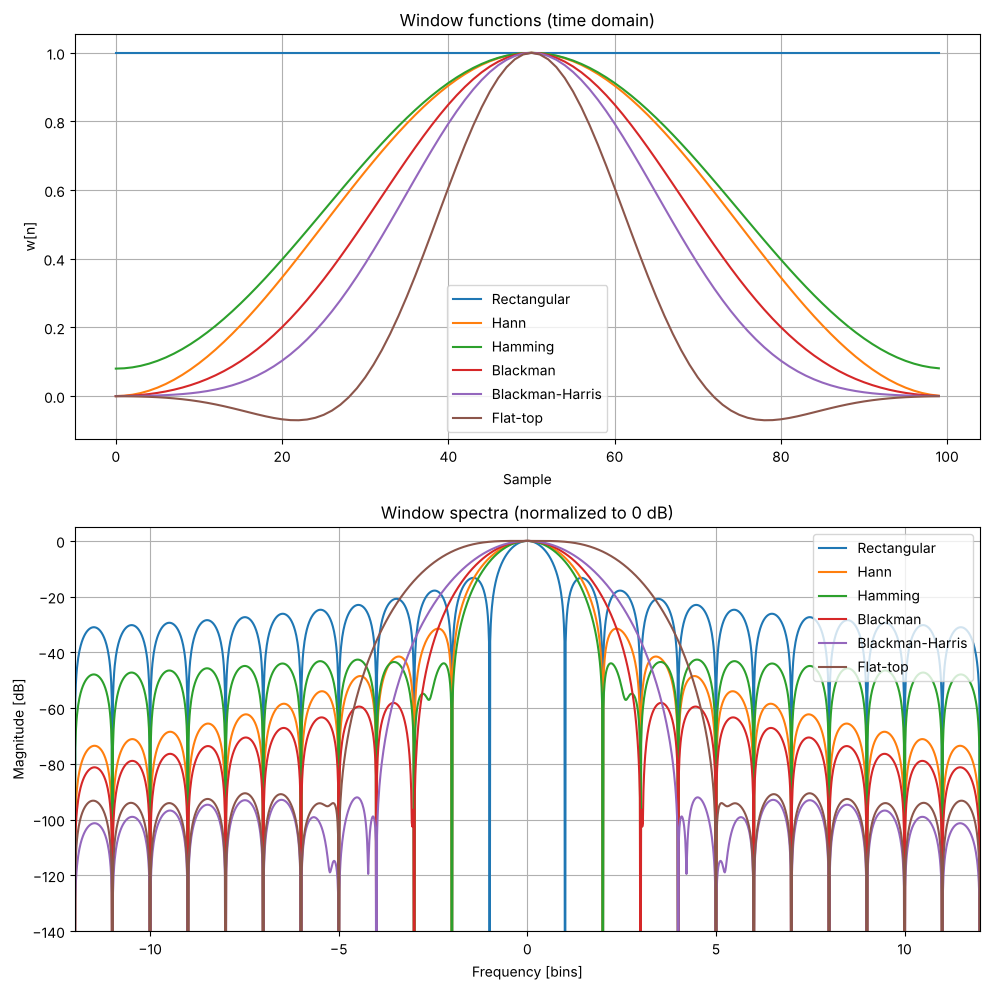

In [10]:
windows = {
    "Rectangular": "boxcar",
    "Hann": "hann",
    "Hamming": "hamming",
    "Blackman": "blackman",
    "Blackman-Harris": "blackmanharris",
    "Flat-top": "flattop",
}

N_win = 100

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

for name, win in windows.items():
    axes[0].plot(get_win(win, N_win), label=name)

    bins, W_db = window_response(win, N_win)
    axes[1].plot(bins, W_db, label=name)

axes[0].set_xlabel("Sample")
axes[0].set_ylabel("w[n]")
axes[0].set_title("Window functions (time domain)")
axes[0].legend()

axes[1].set_xlabel("Frequency [bins]")
axes[1].set_ylabel("Magnitude [dB]")
axes[1].set_title("Window spectra (normalized to 0 dB)")
axes[1].set_xlim(-12, 12)
axes[1].set_ylim(-140, 5)
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

In [11]:
print(f"{'Window':16s} {'-3dB BW':>9s} {'1st null':>9s} {'PSL':>9s} {'CG':>7s} {'CG':>8s} {'ENBW':>7s} {'Scallop':>9s}")
print(f"{'':16s} {'[bins]':>9s} {'[bins]':>9s} {'[dB]':>9s} {'[lin]':>7s} {'[dB]':>8s} {'[bins]':>7s} {'[dB]':>9s}")
print("-" * 82)

metrics = {}
for name, win in windows.items():
    m = window_metrics(win, N_win)
    metrics[name] = m
    print(
        f"{name:16s} {m['bw_3db_bins']:9.2f} {m['null_halfwidth_bins']:9.2f} "
        f"{m['psl_db']:9.1f} {m['coherent_gain']:7.3f} {db20(m['coherent_gain']):8.2f} "
        f"{m['enbw_bins']:7.2f} {m['scalloping_loss_db']:9.2f}"
    )

Window             -3dB BW  1st null       PSL      CG       CG    ENBW   Scallop
                    [bins]    [bins]      [dB]   [lin]     [dB]  [bins]      [dB]
----------------------------------------------------------------------------------
Rectangular           0.91      1.00     -13.3   1.000     0.00    1.00     -3.92
Hann                  1.47      2.00     -31.5   0.500    -6.02    1.50     -1.42
Hamming               1.31      2.00     -42.6   0.540    -5.35    1.36     -1.75
Blackman              1.66      3.00     -58.1   0.420    -7.54    1.73     -1.10
Blackman-Harris       1.91      4.00     -92.0   0.359    -8.90    2.00     -0.83
Flat-top              3.75      5.00     -90.5   0.216   -13.33    3.77     -0.01


### Observation

- As the bells get thinner, edges get softer but for some windows, edges get so soft that some data losses could occur.
- There is a clear trade-off: as the main lobe gets wider, side lobes get smaller.

## Experiment 6: Windowing an Off-Bin Tone

Apply the windows from Experiment 5 to the same off-bin tone used in Experiment 2 (105 Hz, half a bin away from the grid).

The spectra are amplitude-normalized using $\sum w[n]$, so the readings are directly comparable.

The purpose is to see how each window changes the leakage pattern of a tone that falls in the worst possible position.

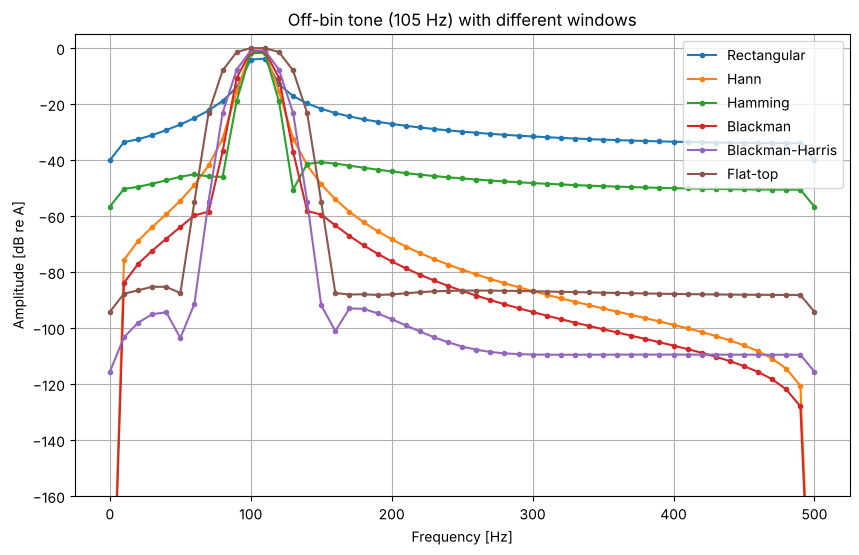

Window            Peak reading     Error  Bins > -60 dB
Rectangular              0.974    -3.75dB             51
Hann                     1.273    -1.42dB             14
Hamming                  1.229    -1.73dB             51
Blackman                 1.322    -1.10dB             10
Blackman-Harris          1.364    -0.83dB              8
Flat-top                 1.498    -0.01dB             10


In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

for name, win in windows.items():
    f_one, amp = amplitude_spectrum(x_off, fs, window=win)
    ax.plot(f_one, db20(amp / A), marker=".", label=name)

ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Amplitude [dB re A]")
ax.set_title("Off-bin tone (105 Hz) with different windows")
ax.set_ylim(-160, 5)
ax.legend(loc="upper right")
plt.show()

print(f"{'Window':16s} {'Peak reading':>13s} {'Error':>9s} {'Bins > -60 dB':>14s}")
for name, win in windows.items():
    _, amp = amplitude_spectrum(x_off, fs, window=win)
    peak = np.max(amp)
    print(f"{name:16s} {peak:13.3f} {db20(peak / A):8.2f}dB {np.sum(db20(amp / A) > -60):14d}")

### Observation *(AI-assisted)

- The peak reading errors match the scalloping loss values from Experiment 5 (e.g. Rectangular −3.75 dB, Hann −1.42 dB, Flat-top −0.01 dB). The small differences come from the mirror component at −105 Hz.
- Tapered windows reduce the peak reading error compared to the rectangular window. Flat-top reads the amplitude almost exactly (1.498 vs. the true value 1.5).
- The cost is a wider main lobe: the more accurately a window reads the peak, the wider the tone appears. Flat-top is only about −1.4 dB at 90 and 120 Hz, so a single tone looks like a flat peak roughly 4 bins wide.
- Far from the tone, the leakage level depends strongly on the window: about −30 dB for the rectangular window, but below −100 dB for Blackman-Harris. The number of bins above −60 dB drops from 51 (Rectangular) to 8 (Blackman-Harris).
- Hamming has lower sidelobes than Hann close to the main lobe (PSL −42.6 dB vs. −31.5 dB), but its sidelobes stay nearly flat with distance, while Hann's fall off quickly. As a result, Hamming leaves 51 bins above −60 dB, while Hann leaves only 14. A lower PSL does not guarantee less leakage far from the tone.

## Experiment 7: Dynamic Range — Weak Tones Next to a Strong Tone

Create a strong tone with two much weaker tones:

| Tone | Frequency | Level |
| --- | --- | --- |
| Strong | 105 Hz | 0 dB |
| Weak 1 | 185 Hz (8 bins away) | −60 dB |
| Weak 2 | 305 Hz (20 bins away) | −80 dB |

No noise is added, so the only thing that can hide the weak tones is leakage from the strong one.

The dashed lines mark where the weak tones are and how strong they really are. As a reference, the same spectrum is also computed with the weak tones removed.

The purpose is to observe which windows allow the weak tones to be detected. This situation is very common in a spectrum analyzer or SDR receiver, where a strong carrier sits next to weak signals.

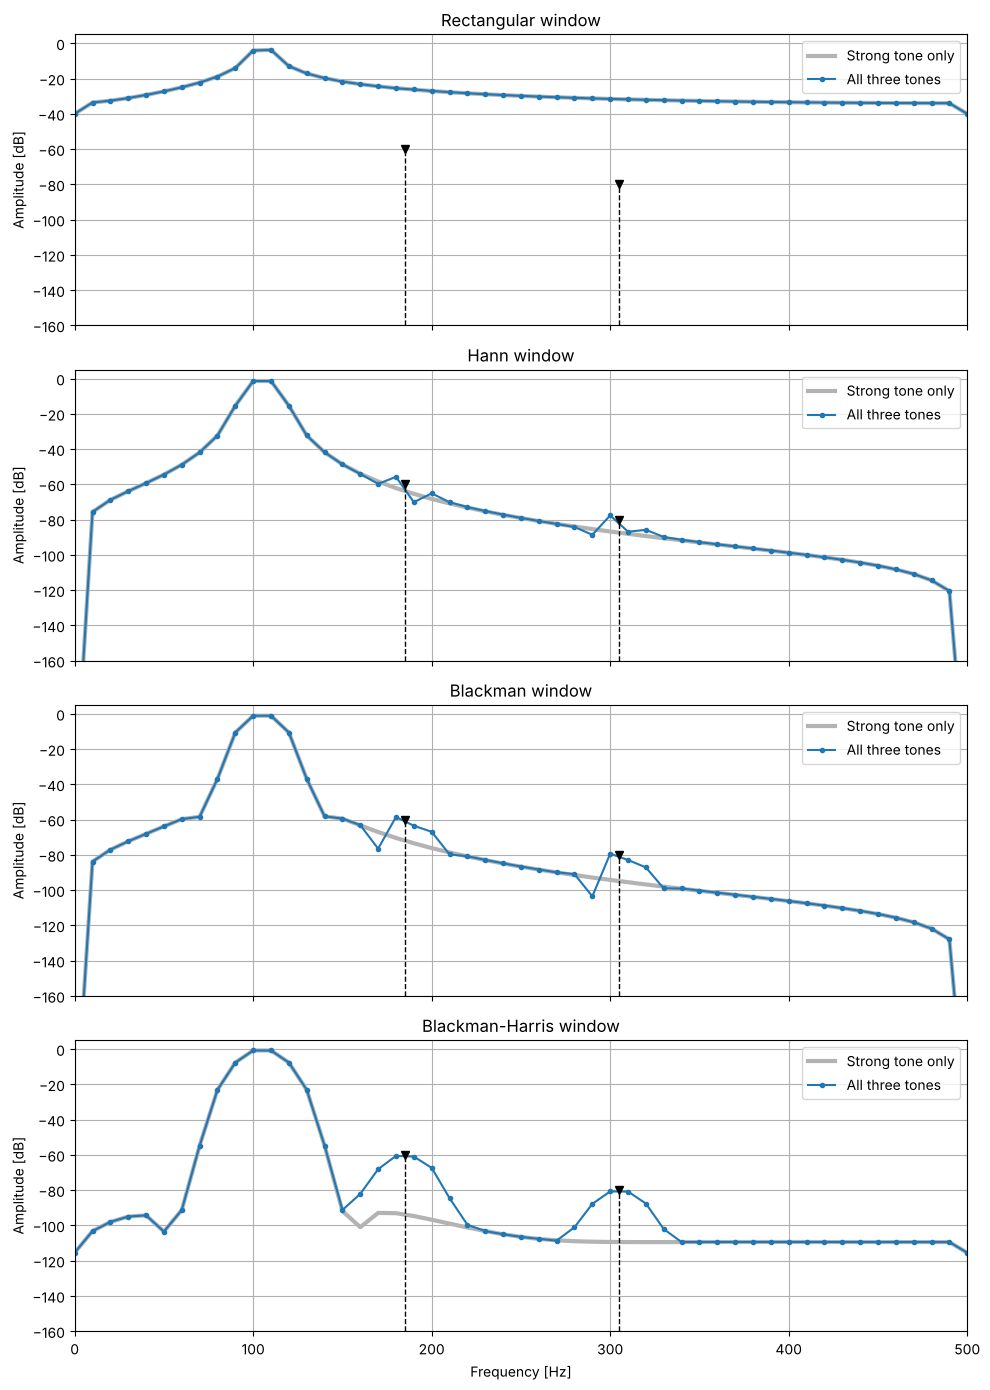

Window            Reading at 185 Hz  Reading at 305 Hz
Rectangular                -25.5 dB           -31.6 dB
Hann                       -55.8 dB           -77.7 dB
Blackman                   -58.5 dB           -79.4 dB
Blackman-Harris            -60.6 dB           -80.8 dB


In [13]:
tones = [
    (105, 0),     # (frequency [Hz], level [dB])
    (185, -60),
    (305, -80),
]

x_dr = sum(10 ** (lvl / 20) * np.cos(2 * np.pi * f * t) for f, lvl in tones)
x_strong_only = np.cos(2 * np.pi * tones[0][0] * t)

windows_dr = ["Rectangular", "Hann", "Blackman", "Blackman-Harris"]

fig, axes = plt.subplots(len(windows_dr), 1, figsize=(10, 14), sharex=True)

for ax, name in zip(axes, windows_dr):
    win = windows[name]
    f_one, amp = amplitude_spectrum(x_dr, fs, window=win)
    _, amp_ref = amplitude_spectrum(x_strong_only, fs, window=win)

    ax.plot(f_one, db20(amp_ref), color="0.7", linewidth=3, label="Strong tone only")
    ax.plot(f_one, db20(amp), marker=".", label="All three tones")

    for f, lvl in tones[1:]:
        ax.plot([f, f], [-160, lvl], "k--", linewidth=1)
        ax.plot(f, lvl, "kv")

    ax.set_ylim(-160, 5)
    ax.set_ylabel("Amplitude [dB]")
    ax.set_title(f"{name} window")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Frequency [Hz]")
axes[-1].set_xlim(0, 500)
plt.tight_layout()
plt.show()

print(f"{'Window':16s} {'Reading at 185 Hz':>18s} {'Reading at 305 Hz':>18s}")
for name in windows_dr:
    f_one, amp = amplitude_spectrum(x_dr, fs, window=windows[name])
    r1 = db20(amp[np.argmin(np.abs(f_one - 185))])
    r2 = db20(amp[np.argmin(np.abs(f_one - 305))])
    print(f"{name:16s} {r1:15.1f} dB {r2:15.1f} dB")

### Observation *(AI-assisted)*

- No noise is added, so the only thing that can hide the weak tones is leakage from the strong tone. A weak tone is visible only if it rises above the strong tone's skirt (the grey reference curve).
- Rectangular: the skirt is about −25 dB at 185 Hz and −32 dB at 305 Hz, so both weak tones are buried 35–50 dB below it. The readings (−25.5 dB and −31.6 dB) belong entirely to the strong tone's leakage, not to the weak tones.
- Hann: the 185 Hz tone is roughly at the same level as the skirt (≈ −62 dB), so the two add up and the tone reads −55.8 dB instead of −60 dB. The tone becomes visible, but its level is measured incorrectly. The 305 Hz tone is clearer because Hann's sidelobes fall off quickly with distance.
- Blackman: both tones rise above the skirt, but the reading at 185 Hz is still about 2–3 dB too high because of leakage.
- Blackman-Harris: the skirt is about 30 dB below both tones, and the readings (−60.6 dB and −80.8 dB) are close to the true levels. The small remaining error is the scalloping loss of the weak tones themselves.
- What matters is not the window alone, but the margin between the weak tone and the strong tone's skirt at the weak tone's frequency. A larger margin means the weak tone is first detected, then measured correctly.
- This holds because the weak tones are 8 and 20 bins away from the strong tone. If a weak tone were within a few bins, the wide main lobe of Blackman-Harris could hide it, and a narrower window would do better.

## Experiment 8: Resolving Two Close Tones of Equal Amplitude

Generate two equal-amplitude tones separated by 1.5, 2 and 3 bins. To show the true shape of the spectrum between bins, each spectrum is zero-padded by 32 (the resolution is still set by $N = 100$).

The purpose is to observe how the windows that performed well in Experiment 7 behave when the task is to separate two neighbouring tones of similar strength.

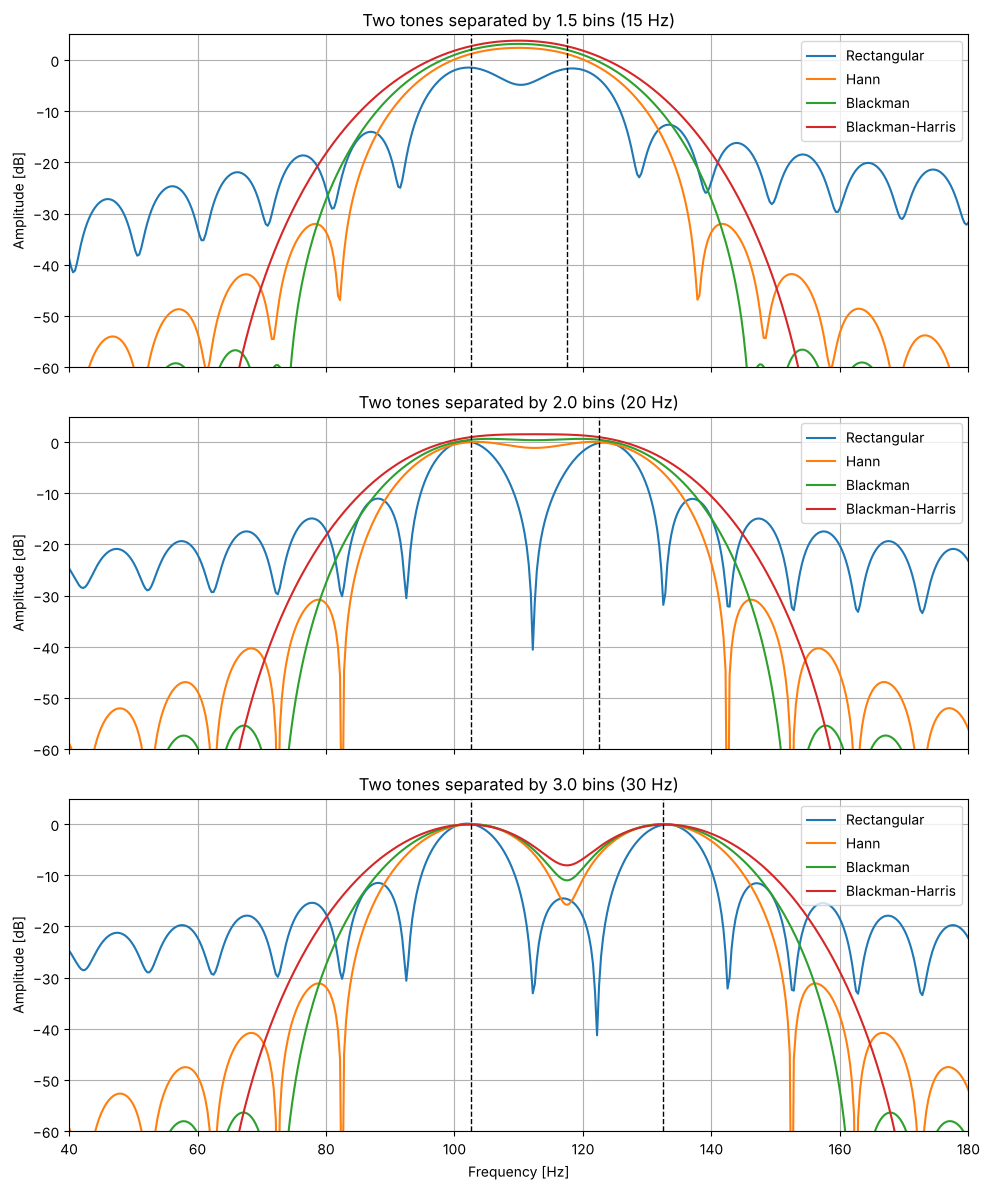

In [14]:
spacings = [1.5, 2.0, 3.0]        # in bins
f_first = 102.5                   # Hz
phase_second = 1.0                # rad, fixed relative phase between the two tones
windows_res = ["Rectangular", "Hann", "Blackman", "Blackman-Harris"]

fig, axes = plt.subplots(len(spacings), 1, figsize=(10, 12), sharex=True)

for ax, sp in zip(axes, spacings):
    f_second = f_first + sp * delta_f
    x = np.cos(2 * np.pi * f_first * t) + np.cos(2 * np.pi * f_second * t + phase_second)

    for name in windows_res:
        f_one, amp = amplitude_spectrum(x, fs, window=windows[name], nfft=N * 32)
        ax.plot(f_one, db20(amp), label=name)

    ax.axvline(f_first, color="k", linestyle="--", linewidth=1)
    ax.axvline(f_second, color="k", linestyle="--", linewidth=1)
    ax.set_xlim(40, 180)
    ax.set_ylim(-60, 5)
    ax.set_ylabel("Amplitude [dB]")
    ax.set_title(f"Two tones separated by {sp} bins ({sp * delta_f:.0f} Hz)")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Frequency [Hz]")
plt.tight_layout()
plt.show()

### Observation

- 

## Experiment 9: Amplitude Accuracy and Scalloping Loss

Repeat the frequency sweep of Experiment 3, but this time for every window. For each fractional offset, read the amplitude as the largest bin of the amplitude-normalized spectrum (no zero-padding) and compute the error relative to the true amplitude.

The purpose is to compare how accurately each window measures the amplitude of a tone whose frequency is not known in advance.

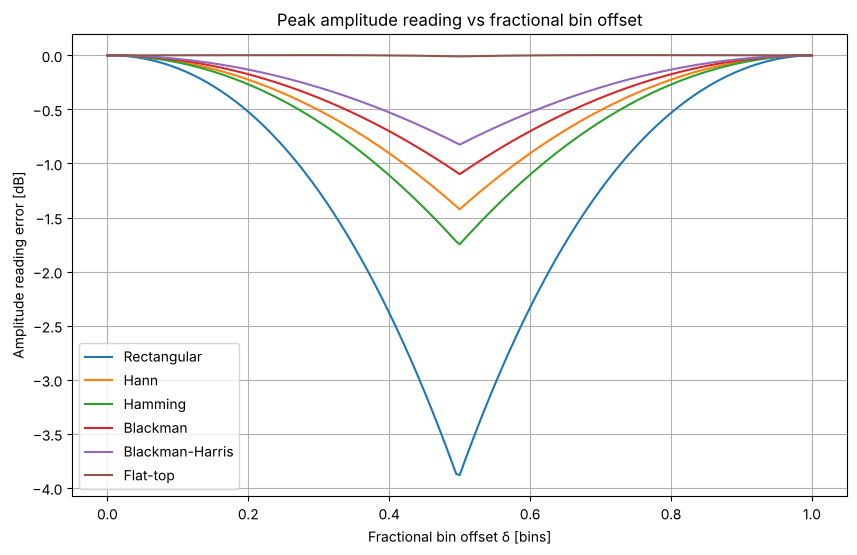

Window            Worst-case error
Rectangular              -3.882 dB
Hann                     -1.424 dB
Hamming                  -1.747 dB
Blackman                 -1.099 dB
Blackman-Harris          -0.826 dB
Flat-top                 -0.010 dB


In [15]:
offsets = np.linspace(0, 1, 201)

plt.figure(figsize=(10, 6))

worst_case = {}
for name, win in windows.items():
    errors = []
    for d in offsets:
        x = np.cos(2 * np.pi * (k0 + d) * delta_f * t)
        _, amp = amplitude_spectrum(x, fs, window=win)
        errors.append(db20(np.max(amp)))
    errors = np.array(errors)
    worst_case[name] = errors.min()
    plt.plot(offsets, errors, label=name)

plt.xlabel("Fractional bin offset δ [bins]")
plt.ylabel("Amplitude reading error [dB]")
plt.title("Peak amplitude reading vs fractional bin offset")
plt.legend()
plt.show()

print(f"{'Window':16s} {'Worst-case error':>17s}")
for name, err in worst_case.items():
    print(f"{name:16s} {err:14.3f} dB")

### Observation

- 

## Experiment 10: Noise Floor and Equivalent Noise Bandwidth

Add white Gaussian noise to an on-bin tone and compute the spectrum with different windows using two common scalings of `scipy.signal.periodogram`:

- `scaling="spectrum"`: power spectrum in V², where a sinusoid of amplitude $A$ reads $A^2/2$.
- `scaling="density"`: power spectral density in V²/Hz.

For each window, measure the average noise floor (excluding the region around the tone) and the tone peak, and compare the differences with $10\log_{10}(ENBW)$ from Experiment 5.

The purpose is to see how a window affects the noise floor, and why the choice of spectral scaling matters when reading SNR or noise levels from a plot. This links directly to the noise floor and detection threshold topics later in the roadmap.

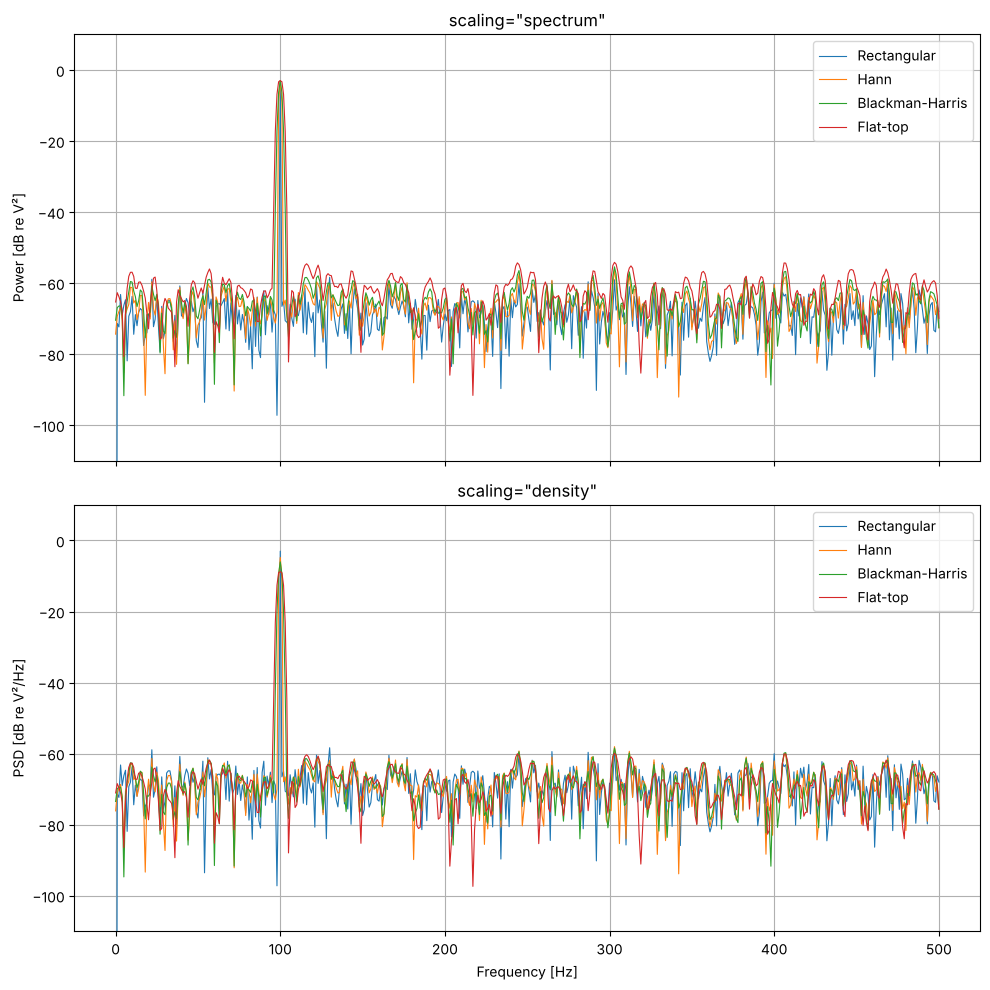

In [16]:
fs_n = 1000
N_n = 1000
t_n = np.arange(N_n) / fs_n
A_n = 1.0
sigma = 0.01                      # noise standard deviation

x_noisy = A_n * np.cos(2 * np.pi * 100 * t_n) + sigma * rng.standard_normal(N_n)

windows_noise = ["Rectangular", "Hann", "Blackman-Harris", "Flat-top"]

fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
results = {}

for name in windows_noise:
    win = windows[name]
    for ax, scaling in zip(axes, ["spectrum", "density"]):
        f_p, P = signal.periodogram(x_noisy, fs=fs_n, window=win, scaling=scaling)
        ax.plot(f_p, 10 * np.log10(P), label=name, linewidth=0.8)

        noise_mask = np.abs(f_p - 100) > 30
        noise_mask[0] = False
        floor_db = 10 * np.log10(np.mean(P[noise_mask]))
        peak_db = 10 * np.log10(np.max(P))
        results[(name, scaling)] = (floor_db, peak_db)

axes[0].set_ylabel("Power [dB re V²]")
axes[0].set_title('scaling="spectrum"')
axes[1].set_ylabel("PSD [dB re V²/Hz]")
axes[1].set_title('scaling="density"')
axes[1].set_xlabel("Frequency [Hz]")

for ax in axes:
    ax.set_ylim(-110, 10)
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [17]:
print(f"Tone: A = {A_n} -> A^2/2 = {10 * np.log10(A_n**2 / 2):.2f} dB re V²")
print(f"Noise: sigma^2 = {sigma**2:.1e} V²\n")

rect_floor = {s: results[("Rectangular", s)][0] for s in ["spectrum", "density"]}
rect_peak = {s: results[("Rectangular", s)][1] for s in ["spectrum", "density"]}

for scaling in ["spectrum", "density"]:
    print(f'scaling="{scaling}"')
    print(f"{'Window':16s} {'Floor':>8s} {'Peak':>8s} {'Floor-Rect':>11s} {'Peak-Rect':>10s} {'10log10(ENBW)':>14s}")
    for name in windows_noise:
        floor_db, peak_db = results[(name, scaling)]
        enbw_db = 10 * np.log10(window_metrics(windows[name], N_n)["enbw_bins"])
        print(
            f"{name:16s} {floor_db:8.2f} {peak_db:8.2f} "
            f"{floor_db - rect_floor[scaling]:11.2f} {peak_db - rect_peak[scaling]:10.2f} {enbw_db:14.2f}"
        )
    print()

Tone: A = 1.0 -> A^2/2 = -3.01 dB re V²
Noise: sigma^2 = 1.0e-04 V²

scaling="spectrum"
Window              Floor     Peak  Floor-Rect  Peak-Rect  10log10(ENBW)
Rectangular        -67.22    -3.01        0.00       0.00           0.00
Hann               -65.31    -3.01        1.91       0.00           1.76
Blackman-Harris    -64.11    -3.01        3.10       0.00           3.02
Flat-top           -61.38    -3.01        5.84      -0.00           5.76

scaling="density"
Window              Floor     Peak  Floor-Rect  Peak-Rect  10log10(ENBW)
Rectangular        -67.22    -3.01        0.00       0.00           0.00
Hann               -67.07    -4.77        0.15      -1.76           1.76
Blackman-Harris    -67.13    -6.03        0.09      -3.02           3.02
Flat-top           -67.14    -8.78        0.07      -5.77           5.76



### Observation

- 

## Extension A: The Kaiser Window as a Tunable Trade-Off

The windows in Experiment 5 each represent one fixed point in the trade-off between main-lobe width and sidelobe level. The Kaiser window has a shape parameter $\beta$ that moves continuously along this trade-off.

Sweep $\beta$, plot the window spectra, and plot the measured peak sidelobe level against the main-lobe half-width. The fixed windows from Experiment 5 are added to the same plot for comparison.

The purpose is to see the trade-off as a continuous curve instead of a list of named windows.

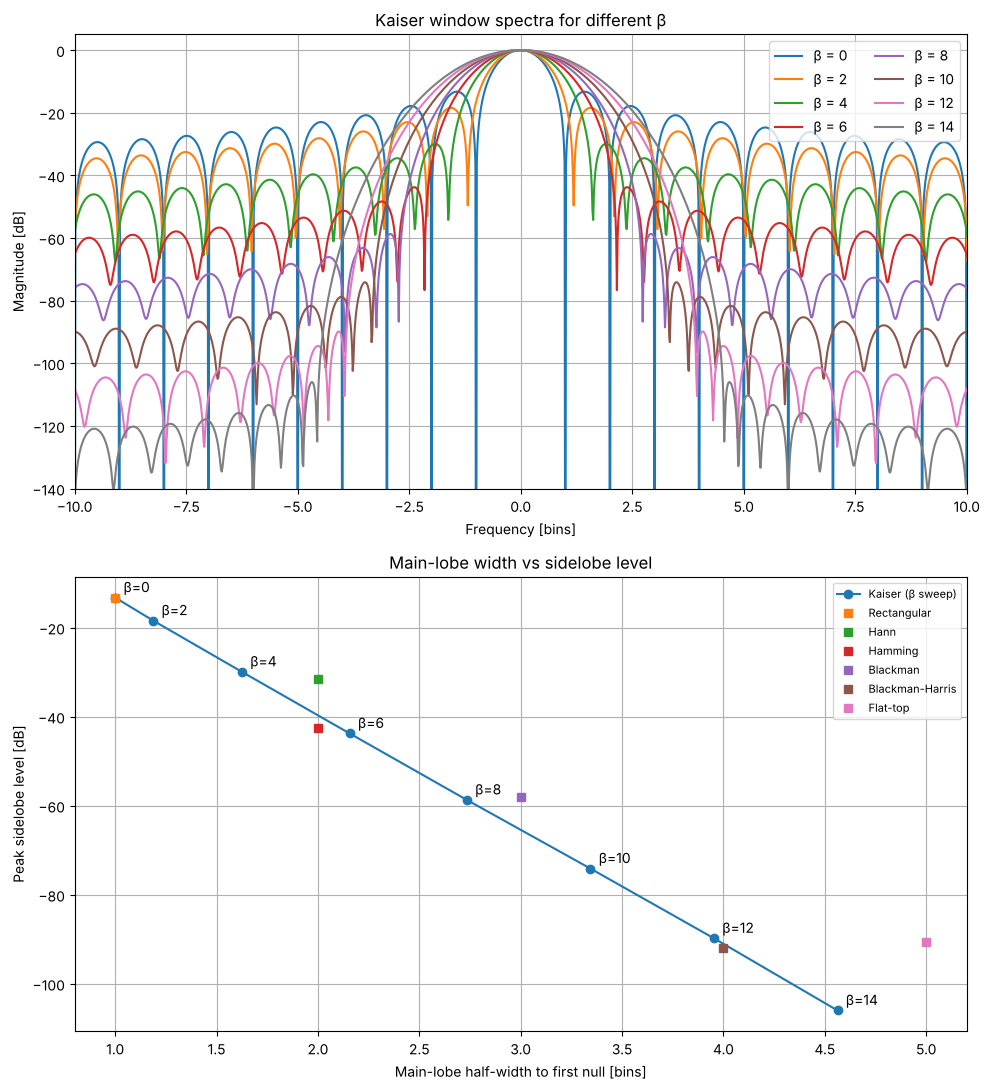

 beta  1st null [bins]   PSL [dB]
    0             1.00      -13.3
    2             1.19      -18.4
    4             1.62      -29.9
    6             2.16      -43.8
    8             2.73      -58.7
   10             3.34      -74.1
   12             3.95      -89.8
   14             4.56     -106.0


In [18]:
betas = [0, 2, 4, 6, 8, 10, 12, 14]

fig, axes = plt.subplots(2, 1, figsize=(10, 11))

kaiser_null, kaiser_psl = [], []
for beta in betas:
    win = ("kaiser", beta)
    bins, W_db = window_response(win, N_win)
    axes[0].plot(bins, W_db, label=f"β = {beta}")

    m = window_metrics(win, N_win)
    kaiser_null.append(m["null_halfwidth_bins"])
    kaiser_psl.append(m["psl_db"])

axes[0].set_xlim(-10, 10)
axes[0].set_ylim(-140, 5)
axes[0].set_xlabel("Frequency [bins]")
axes[0].set_ylabel("Magnitude [dB]")
axes[0].set_title("Kaiser window spectra for different β")
axes[0].legend(loc="upper right", ncol=2)

axes[1].plot(kaiser_null, kaiser_psl, "o-", label="Kaiser (β sweep)")
for beta, xn, yp in zip(betas, kaiser_null, kaiser_psl):
    axes[1].annotate(f"β={beta}", (xn, yp), textcoords="offset points", xytext=(6, 4))

for name, m in metrics.items():
    axes[1].plot(m["null_halfwidth_bins"], m["psl_db"], "s", label=name)

axes[1].set_xlabel("Main-lobe half-width to first null [bins]")
axes[1].set_ylabel("Peak sidelobe level [dB]")
axes[1].set_title("Main-lobe width vs sidelobe level")
axes[1].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

print(f"{'beta':>5s} {'1st null [bins]':>16s} {'PSL [dB]':>10s}")
for beta, xn, yp in zip(betas, kaiser_null, kaiser_psl):
    print(f"{beta:5d} {xn:16.2f} {yp:10.1f}")

### Observation

- 

## Extension B: Complex Baseband (I/Q) Spectrum — An SDR View

An SDR delivers complex I/Q samples, and its spectrum display covers both negative and positive frequencies around the tuned center frequency. Simulate such a capture:

| Signal | Frequency offset | Level |
| --- | --- | --- |
| Strong carrier | +150.3 kHz | 0 dBFS |
| Weak signal 1 | +165.0 kHz | −65 dBFS |
| Weak signal 2 | −220.0 kHz | −80 dBFS |
| Complex white noise | — | per-bin floor around −115 dBFS (rectangular) |

Each signal is a complex exponential $A e^{j 2\pi f n / f_s}$, so it appears only on one side of the spectrum. For complex signals the amplitude spectrum is normalized by $\sum w[n]$ (no factor of 2) and plotted with `fftshift`.

The purpose is to apply the same leakage and windowing ideas in the form they will appear in Phase 4 (SDR and RF lab).

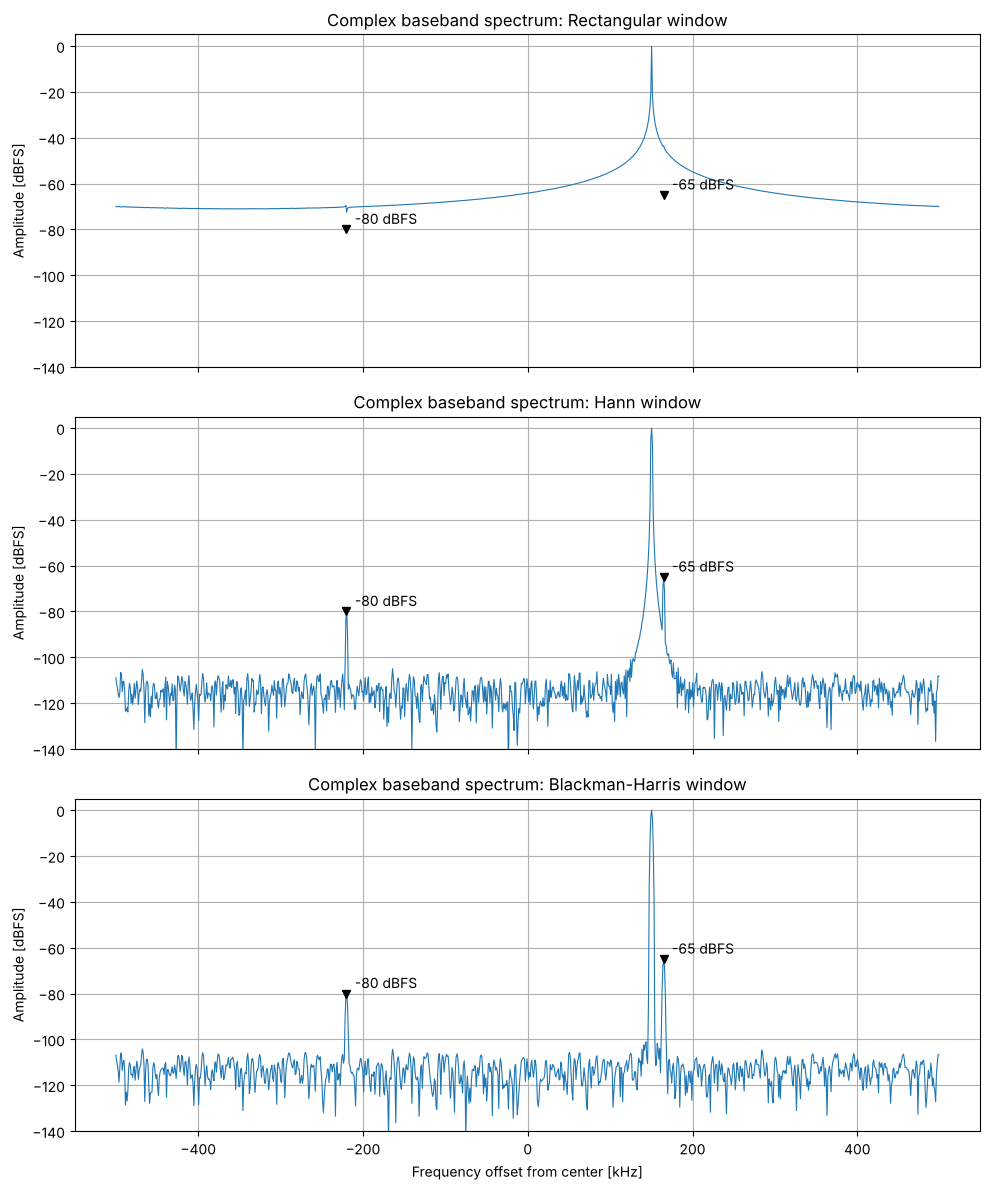

Bin spacing: 976.56 Hz
Carrier bin position: 153.91 (fractional part decides the leakage)


In [19]:
fs_iq = 1e6          # 1 MS/s
N_iq = 1024

n_iq = np.arange(N_iq)

iq_signals = [
    (150.3e3, 0),    # (frequency offset [Hz], level [dBFS])
    (165.0e3, -65),
    (-220.0e3, -80),
]

noise_floor_dbfs = -115          # target per-bin floor with the rectangular window
noise_sigma = np.sqrt(10 ** (noise_floor_dbfs / 10) * N_iq)
noise = noise_sigma / np.sqrt(2) * (rng.standard_normal(N_iq) + 1j * rng.standard_normal(N_iq))

x_iq = sum(10 ** (lvl / 20) * np.exp(2j * np.pi * f * n_iq / fs_iq) for f, lvl in iq_signals) + noise

f_iq = np.fft.fftshift(np.fft.fftfreq(N_iq, d=1 / fs_iq))

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

for ax, name in zip(axes, ["Rectangular", "Hann", "Blackman-Harris"]):
    w = get_win(windows[name], N_iq)
    X_iq = np.fft.fftshift(np.fft.fft(x_iq * w))
    amp_iq = np.abs(X_iq) / np.sum(w)

    ax.plot(f_iq / 1e3, db20(amp_iq), linewidth=0.8)
    for f, lvl in iq_signals[1:]:
        ax.plot(f / 1e3, lvl, "kv")
        ax.annotate(f"{lvl} dBFS", (f / 1e3, lvl), textcoords="offset points", xytext=(6, 4))

    ax.set_ylim(-140, 5)
    ax.set_ylabel("Amplitude [dBFS]")
    ax.set_title(f"Complex baseband spectrum: {name} window")

axes[-1].set_xlabel("Frequency offset from center [kHz]")
plt.tight_layout()
plt.show()

print(f"Bin spacing: {fs_iq / N_iq:.2f} Hz")
print(f"Carrier bin position: {150.3e3 / (fs_iq / N_iq):.2f} (fractional part decides the leakage)")

### Observation

- 

## Key Takeaways

-

## Next Step

The next notebook will investigate the STFT and spectrograms, focusing on the time–frequency resolution trade-off that appears when the FFT is applied to short, sliding windows of a longer signal.